# Selection Algorithm Analysis

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
data=pd.read_csv('ga_selection_analysis2.csv',index_col='Generation')

ValueError: Index Generation invalid

In [ ]:
data.head()

,tournament|positionbased|global_perm|elitism=True|1child,tournament|positionbased|random_swap|elitism=True|1child,tournament|positionbased|between_teams|elitism=True|1child,tournament|blockwise|random_swap|elitism=True|1child,tournament|positionbased_2child|random_swap|elitism=True|2child,tournament|blockwise_2child|between_teams|elitism=True|2child,tournament|positionbased_2child|between_teams|elitism=True|2child,tournament|blockwise_2child|random_swap|elitism=True|2child,fitness_proportionate|positionbased|between_teams|elitism=True|1child,fitness_proportionate|blockwise|global_perm|elitism=True|1child,...,tournament|blockwise_2child|global_perm|elitism=False|2child,tournament|blockwise_2child|random_swap|elitism=False|2child,fitness_proportionate|positionbased|random_swap|elitism=False|1child,fitness_proportionate|blockwise|global_perm|elitism=False|1child,fitness_proportionate|blockwise|random_swap|elitism=False|1child,fitness_proportionate|blockwise|between_teams|elitism=False|1child,fitness_proportionate|blockwise_2child|global_perm|elitism=False|2child,fitness_proportionate|positionbased_2child|random_swap|elitism=False|2child,fitness_proportionate|positionbased_2child|global_perm|elitism=False|2child,fitness_proportionate|blockwise_2child|random_swap|elitism=False|2child
Generation,,,,,,,,,,,,,,,,,,,,,
0,0.658512,0.700551,0.671240,0.685035,0.686146,0.710284,0.726789,0.702852,0.685035,0.693259,...,0.723727,0.693643,0.709620,0.701065,0.676954,0.671240,0.644104,0.631042,0.652295,0.648866
1,0.690115,0.770309,0.693793,0.735184,0.735184,0.710284,0.726789,0.755049,0.700551,0.723483,...,0.755049,0.708849,0.703903,0.700803,0.693793,0.653963,0.696177,0.639789,0.698167,0.738870
2,0.754679,0.778724,0.744854,0.748440,0.738246,0.712759,0.774664,0.766502,0.710284,0.726278,...,0.755049,0.729467,0.648866,0.665685,0.658756,0.692075,0.683977,0.642737,0.702852,0.766249
3,0.754679,0.792894,0.786294,0.774370,0.744854,0.762916,0.783079,0.808331,0.770309,0.748440,...,0.775557,0.738870,0.645654,0.660557,0.653994,0.683016,0.696177,0.671399,0.689269,0.726405
4,0.783079,0.792894,0.790101,0.787780,0.744854,0.814593,0.783079,0.827314,0.778724,0.766502,...,0.797595,0.803461,0.700467,0.681056,0.669439,0.707711,0.705327,0.655294,0.641376,0.700821


In [ ]:
data.tail()

,tournament|positionbased|global_perm|elitism=True|1child,tournament|positionbased|random_swap|elitism=True|1child,tournament|positionbased|between_teams|elitism=True|1child,tournament|blockwise|random_swap|elitism=True|1child,tournament|positionbased_2child|random_swap|elitism=True|2child,tournament|blockwise_2child|between_teams|elitism=True|2child,tournament|positionbased_2child|between_teams|elitism=True|2child,tournament|blockwise_2child|random_swap|elitism=True|2child,fitness_proportionate|positionbased|between_teams|elitism=True|1child,fitness_proportionate|blockwise|global_perm|elitism=True|1child,...,tournament|blockwise_2child|global_perm|elitism=False|2child,tournament|blockwise_2child|random_swap|elitism=False|2child,fitness_proportionate|positionbased|random_swap|elitism=False|1child,fitness_proportionate|blockwise|global_perm|elitism=False|1child,fitness_proportionate|blockwise|random_swap|elitism=False|1child,fitness_proportionate|blockwise|between_teams|elitism=False|1child,fitness_proportionate|blockwise_2child|global_perm|elitism=False|2child,fitness_proportionate|positionbased_2child|random_swap|elitism=False|2child,fitness_proportionate|positionbased_2child|global_perm|elitism=False|2child,fitness_proportionate|blockwise_2child|random_swap|elitism=False|2child
Generation,,,,,,,,,,,,,,,,,,,,,
5,0.783079,0.792894,0.840674,0.814593,0.762916,0.826476,0.792894,0.827314,0.783079,0.770857,...,0.814593,0.811877,0.642657,0.667937,0.660422,0.707711,0.707711,0.691710,0.710284,0.724959
6,0.783079,0.802709,0.858945,0.814593,0.783425,0.857193,0.792894,0.848934,0.783079,0.770857,...,0.848934,0.820136,0.732262,0.685035,0.648866,0.719357,0.685035,0.692075,0.732262,0.741463
7,0.783079,0.802709,0.858945,0.833575,0.787780,0.857193,0.798516,0.857193,0.798516,0.783079,...,0.858945,0.841835,0.685167,0.691492,0.691408,0.751463,0.693643,0.729200,0.715757,0.693643
8,0.787780,0.802709,0.858945,0.848934,0.798516,0.857193,0.798516,0.857193,0.820136,0.783079,...,0.903420,0.827314,0.663316,0.663528,0.675050,0.705237,0.712963,0.682807,0.701065,0.698167
9,0.787780,0.802709,0.858945,0.857193,0.820215,0.890318,0.835573,0.877215,0.829951,0.783079,...,0.903420,0.833575,0.669336,0.717056,0.660422,0.687118,0.648866,0.708277,0.683016,0.712963


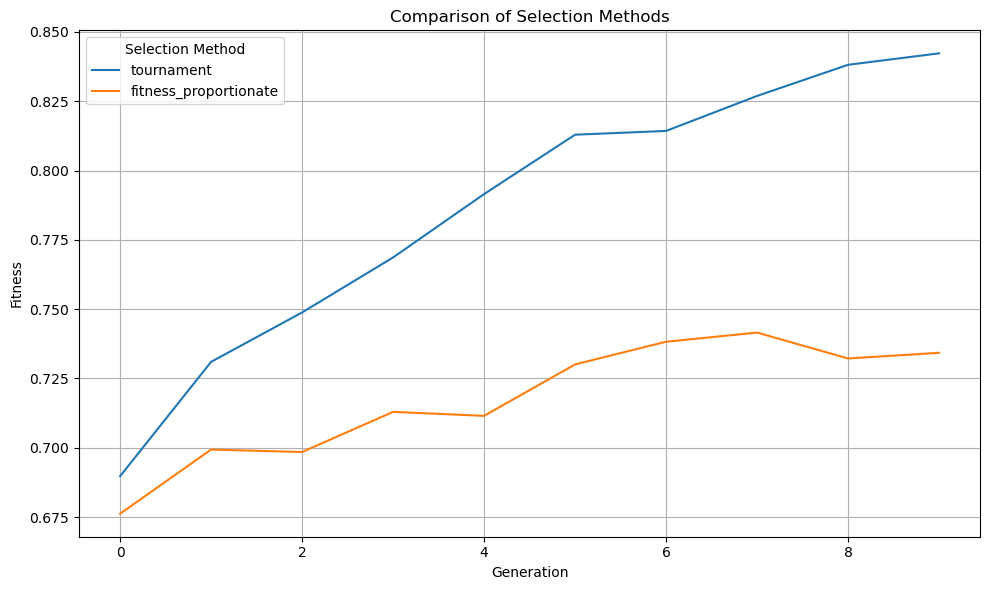

In [ ]:
selection_results = {}

# iterate through each column in the dataset
for col in data.columns:
    selection_method = col.split("|")[0]  # extract "tournament" or "fitness_proportionate"
    #initialize list for each method
    if selection_method not in selection_results:
        selection_results[selection_method] = []
    
    # add column to the appropriate selection method group
    selection_results[selection_method].append(data[col])

# compute the median fitness per generation across all configurations of the same selection method
selection_avg_df = pd.DataFrame({
    method: pd.concat(columns, axis=1).median(axis=1)
    for method, columns in selection_results.items()
})

# plot
plt.figure(figsize=(10, 6))

for method in selection_avg_df.columns:
    plt.plot(selection_avg_df.index, selection_avg_df[method], label=method)

plt.title("Comparison of Selection Methods")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend(title="Selection Method")
plt.grid(True)
plt.tight_layout()
plt.show()

Moving forward we will use the tournament method to evaluate the best combination of crossover and mutation